# RNN Shakespeare — Character-Level Text Generation

**Project 4** in the [DL-Projects](https://github.com/your-repo/DL-Projects) portfolio series.

## The Problem

In Projects 1–3, we used **CNNs** to classify images. CNNs are great at spatial patterns — they slide filters across 2D grids to detect edges, textures, and objects.

But what about **sequential data** where **order matters**?

- Shuffle the pixels of a cat photo → still roughly recognizable
- Shuffle the characters of "to be or not to be" → meaningless

CNNs have no concept of "what came before." For text, music, time series — we need a model that **reads one step at a time** and **remembers** what it's seen.

## The Solution: Recurrent Neural Networks (RNNs)

An RNN processes input **sequentially**, carrying a **hidden state** that acts as its memory. At each timestep, it combines the current input with its memory of the past to produce an output and an updated memory.

In this project, we build a **character-level vanilla RNN** that learns to generate Shakespeare text — one character at a time — trained from scratch on the Tiny Shakespeare dataset.

### What You'll See

| Concept | Where |
|---------|-------|
| One-hot encoding | Section 3 |
| Hidden states & sequential memory | Section 3 |
| Backpropagation Through Time (BPTT) | Section 3 |
| Custom PyTorch Dataset | Section 2 |
| Gradient clipping | Section 5 |
| Perplexity metric | Section 5 |
| Temperature-controlled generation | Section 7 |

---
## 1. Setup

In [1]:
import os
import math
import urllib.request

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

# Device detection: Colab T4 GPU > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"PyTorch {torch.__version__}")
print(f"Device: {device}")

PyTorch 2.10.0+cu128
Device: cuda


---
## 2. Dataset — Tiny Shakespeare

Unlike MNIST/CIFAR-10 where `torchvision.datasets` gave us ready-made (image, label) pairs, there's no built-in dataset for raw text. We'll:

1. **Download** the text file
2. **Explore** what's in it
3. **Build a vocabulary** (character ↔ integer mapping)
4. **Create a custom `Dataset`** class

### 2.1 Download & Explore

In [2]:
# Download Tiny Shakespeare (~1.1 MB of Shakespeare plays)
DATA_PATH = "input.txt"
SHAKESPEARE_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

if not os.path.exists(DATA_PATH):
    print("Downloading Tiny Shakespeare...")
    urllib.request.urlretrieve(SHAKESPEARE_URL, DATA_PATH)

with open(DATA_PATH, "r") as f:
    text = f.read()

print(f"Total characters: {len(text):,}")
print(f"Total lines: {text.count(chr(10)):,}")
print(f"\nFirst 500 characters:")
print("=" * 50)
print(text[:500])

Total characters: 1,115,394
Total lines: 40,000

First 500 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [3]:
# What characters does Shakespeare use?
chars = sorted(set(text))
vocab_size = len(chars)

print(f"Vocabulary size: {vocab_size} unique characters")
print(f"\nCharacters: {repr(''.join(chars))}")

Vocabulary size: 65 unique characters

Characters: "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"


65 characters: newline, space, punctuation, uppercase A-Z, lowercase a-z, and a few special symbols. The model will learn to predict the next one from this set.

### 2.2 Character ↔ Integer Mapping

Neural networks work with numbers, not characters. We need two dictionaries:
- `char_to_idx`: `'A'` → `10` (for encoding input)
- `idx_to_char`: `10` → `'A'` (for decoding output)

In [4]:
# sorted() makes the mapping deterministic — without it, set() gives a random
# order each time, and yesterday's trained model wouldn't match today's vocab
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}

# Demo: encode and decode
sample = "To be"
encoded = [char_to_idx[ch] for ch in sample]
decoded = "".join([idx_to_char[i] for i in encoded])

print(f"'{sample}' → {encoded} → '{decoded}'")

'To be' → [32, 53, 1, 40, 43] → 'To be'


In [5]:
# Encode the entire text as a tensor of indices
# dtype=torch.long because CrossEntropyLoss requires 64-bit integer targets
encoded_text = torch.tensor([char_to_idx[ch] for ch in text], dtype=torch.long)

print(f"Encoded shape: {encoded_text.shape}")
print(f"First 20 indices: {encoded_text[:20].tolist()}")
print(f"Decoded back:     '{text[:20]}'")

Encoded shape: torch.Size([1115394])
First 20 indices: [18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10, 0, 14, 43, 44, 53, 56]
Decoded back:     'First Citizen:
Befor'


### 2.3 Custom Dataset

How do we turn one long sequence of characters into training samples?

We slice it into **non-overlapping chunks** of `seq_len=100` characters. For each chunk, the **target** is the same text **shifted by 1 character**:

```
Input:  T  h  e     k  i  n  g     s
Target: h  e     k  i  n  g     s  a
```

At every position, the RNN learns: "given everything up to here, what's the next character?"

This is different from CNN projects where each sample was independent (one image, one label). Here, the **sequential order within each sample** is what the model learns from.

In [6]:
class ShakespeareDataset(Dataset):
    """
    Character-level dataset: slices encoded text into non-overlapping chunks.

    Each sample:
        input  = text[i*seq_len : (i+1)*seq_len]       # chars 0..99
        target = text[i*seq_len+1 : (i+1)*seq_len+1]   # chars 1..100 (shifted by 1)
    """
    def __init__(self, encoded_text, seq_len):
        self.data = encoded_text
        self.seq_len = seq_len
        # (len - 1) because target is shifted by 1: last sample needs one extra char
        self.num_samples = (len(encoded_text) - 1) // seq_len

    # PyTorch DataLoader calls these two methods:
    #   __len__()         — "how many samples do you have?"
    #   __getitem__(idx)  — "give me sample number idx"
    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        start = idx * self.seq_len
        x = self.data[start : start + self.seq_len]          # (seq_len,) input
        y = self.data[start + 1 : start + self.seq_len + 1]  # (seq_len,) target, shifted by 1
        return x, y

In [7]:
# Split: 80% train / 10% val / 10% test (contiguous, not random —
# shuffling would destroy the sequential structure within splits)
SEQ_LEN = 100
BATCH_SIZE = 64

n = len(encoded_text)
train_end = int(n * 0.8)
val_end = int(n * 0.9)

train_dataset = ShakespeareDataset(encoded_text[:train_end], SEQ_LEN)
val_dataset   = ShakespeareDataset(encoded_text[train_end:val_end], SEQ_LEN)
test_dataset  = ShakespeareDataset(encoded_text[val_end:], SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Sequences — Train: {len(train_dataset):,} | Val: {len(val_dataset):,} | Test: {len(test_dataset):,}")
print(f"Batches   — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Sequences — Train: 8,923 | Val: 1,115 | Test: 1,115
Batches   — Train: 140 | Val: 18 | Test: 18


In [8]:
# Verify: grab one batch and check the input/target shift
x_batch, y_batch = next(iter(train_loader))
print(f"Input shape:  {x_batch.shape}")   # (64, 100)
print(f"Target shape: {y_batch.shape}")   # (64, 100)

# Show the shift: target is input shifted by 1 character
sample_input  = "".join([idx_to_char[i.item()] for i in x_batch[0][:30]])
sample_target = "".join([idx_to_char[i.item()] for i in y_batch[0][:30]])
print(f"\nInput:  '{sample_input}'")
print(f"Target: '{sample_target}'")
print(f"         {'':>1}↑ shifted by 1 character")

Input shape:  torch.Size([64, 100])
Target shape: torch.Size([64, 100])

Input:  '
Were he more angry at it.

ME'
Target: 'Were he more angry at it.

MEN'
          ↑ shifted by 1 character


---
## 3. Key Concepts

Before building the model, let's understand the three core ideas that make RNNs work.

### 3.1 One-Hot Encoding

We can't feed raw integers (like `20` for `'T'`) into a neural network — the network would think `'T'` (20) is "bigger" than `'A'` (10), implying a relationship that doesn't exist.

**One-hot encoding** converts each character to a vector of length 65 where exactly one position is 1:

In [9]:
# One-hot encoding demo
char = 'A'
idx = char_to_idx[char]
one_hot = F.one_hot(torch.tensor(idx), num_classes=vocab_size)

print(f"'{char}' → index {idx} → one-hot vector (length {vocab_size}):")
print(f"{one_hot.tolist()}")
print(f"\nOnly position {idx} is 1, everything else is 0.")
print(f"This tells the network: 'this is character {idx}' without implying any ordering.")

'A' → index 13 → one-hot vector (length 65):
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Only position 13 is 1, everything else is 0.
This tells the network: 'this is character 13' without implying any ordering.


In [10]:
# For a batch: (N, seq_len) → (N, seq_len, vocab_size)
sample_indices = torch.tensor([[20, 45, 41]])  # "The"
sample_onehot = F.one_hot(sample_indices, num_classes=vocab_size).float()
print(f"Indices shape: {sample_indices.shape}")     # (1, 3)
print(f"One-hot shape: {sample_onehot.shape}")      # (1, 3, 65)
print(f"\nEach of the 3 characters becomes a 65-dim vector.")
print(f"The .float() is needed because nn.RNN expects float inputs, not integers.")

Indices shape: torch.Size([1, 3])
One-hot shape: torch.Size([1, 3, 65])

Each of the 3 characters becomes a 65-dim vector.
The .float() is needed because nn.RNN expects float inputs, not integers.


### 3.2 Hidden States — The RNN's Memory

Think of reading a book. At each word, your brain updates its "understanding so far." The hidden state is exactly that — a vector that gets **updated at every timestep** and carries context forward.

At each timestep t, the RNN computes:

$$h_t = \tanh(W_{ih} \cdot x_t + W_{hh} \cdot h_{t-1} + b)$$

- **x_t**: current input (one-hot character)
- **h_{t-1}**: previous hidden state (memory so far)
- **W_ih, W_hh**: learned weight matrices
- **tanh**: squashes output to [-1, 1]

This is the same operation at every timestep — the same weights process every character. The only thing that changes is the hidden state, which accumulates context.

In [11]:
# Demo: watch the hidden state change as the RNN reads character by character
demo_rnn = nn.RNN(input_size=vocab_size, hidden_size=8, batch_first=True)  # tiny hidden for demo

demo_text = "Hello"
demo_indices = torch.tensor([[char_to_idx[ch] for ch in demo_text]])
demo_onehot = F.one_hot(demo_indices, num_classes=vocab_size).float()

# Feed one character at a time to see hidden state evolving
hidden = None
print("Watching the hidden state evolve as the RNN reads 'Hello':")
print("=" * 60)

for i, ch in enumerate(demo_text):
    single_char = demo_onehot[:, i:i+1, :]  # (1, 1, 65) — one character
    _, hidden = demo_rnn(single_char, hidden)
    h_vals = hidden.squeeze().detach().numpy()
    print(f"After '{ch}': hidden = [{', '.join(f'{v:+.3f}' for v in h_vals)}]")

print(f"\nThe hidden state changes after every character — it's the RNN's")
print(f"running memory of everything it has read so far.")

Watching the hidden state evolve as the RNN reads 'Hello':
After 'H': hidden = [-0.291, +0.207, +0.241, -0.087, -0.068, -0.162, -0.245, -0.479]
After 'e': hidden = [-0.527, +0.178, +0.109, -0.137, -0.053, +0.157, -0.394, -0.351]
After 'l': hidden = [-0.082, +0.410, -0.083, -0.325, -0.375, -0.084, -0.504, -0.024]
After 'l': hidden = [-0.335, +0.472, -0.101, -0.355, -0.330, -0.328, -0.602, +0.086]
After 'o': hidden = [-0.131, -0.024, -0.394, -0.413, +0.086, -0.222, -0.235, -0.200]

The hidden state changes after every character — it's the RNN's
running memory of everything it has read so far.


### 3.3 Backpropagation Through Time (BPTT)

In CNN projects, backprop flowed through ~5-10 layers. In an RNN with `seq_len=100`, the computation graph is **100 timesteps deep** — the same weight matrix $W_{hh}$ is applied 100 times.

When `loss.backward()` runs, PyTorch **unrolls** the RNN and computes gradients through all 100 timesteps. This is BPTT — the same chain rule from DLFS Chapter 4, but applied 100 times in sequence.

**The problem:** Multiplying by $W_{hh}$ at each step means gradients get multiplied ~100 times:
- If the largest eigenvalue of $W_{hh}$ > 1: gradients **explode** → huge parameter updates → training diverges
- If the largest eigenvalue of $W_{hh}$ < 1: gradients **vanish** → early timesteps barely learn

**Our solution for exploding gradients:** `clip_grad_norm_` — after `backward()`, cap the total gradient magnitude before `step()`. We'll see this in the training loop.

**Vanishing gradients** are harder to fix and are the reason LSTMs exist — that's the next project.

---
## 4. Model Architecture

```
Input (N, 100)            — character indices (integers 0-64)
  → One-hot (N, 100, 65)  — each char becomes a 65-dim vector
  → nn.RNN (N, 100, 512)  — hidden state updated at each timestep
  → nn.Linear (N, 100, 65) — logits for next character prediction
```

Only two learnable layers: `nn.RNN` and `nn.Linear`. The one-hot encoding is a fixed transformation (no learnable parameters).

In [12]:
class ShakespeareRNN(nn.Module):
    """
    Character-level vanilla RNN for text generation.

    Pipeline:
        Input (N, seq_len)           — character indices
        → One-hot (N, seq_len, 65)   — one-hot encoded
        → RNN (N, seq_len, 512)      — hidden state at each timestep
        → Linear (N, seq_len, 65)    — logits for next character
    """
    def __init__(self, vocab_size, hidden_size=512):
        super().__init__()
        self.vocab_size = vocab_size    # Needed in forward() for one-hot encoding
        self.hidden_size = hidden_size

        # RNN: at each timestep, takes a 65-dim one-hot vector + previous hidden state
        #      → outputs a new 512-dim hidden state
        self.rnn = nn.RNN(
            input_size=vocab_size,       # 65 (one-hot size)
            hidden_size=hidden_size,     # 512
            num_layers=1,                # Single layer vanilla RNN
            batch_first=True,            # Input shape: (N, seq_len, input_size)
        )

        # Linear: maps 512-dim hidden state → 65 logits (one per character)
        self.fc = nn.Linear(hidden_size, vocab_size)  # (N, seq_len, 512) → (N, seq_len, 65)

    def forward(self, x, hidden=None):
        """
        x: (N, seq_len) — character indices
        hidden: (1, N, hidden_size) — optional initial hidden state
        Returns: (logits, hidden)
        """
        # Step 1: One-hot encode input indices
        # (N, seq_len) → (N, seq_len, vocab_size)
        x = F.one_hot(x, num_classes=self.vocab_size).float()

        # Step 2: RNN forward — pass one-hot + previous hidden state
        # out: (N, seq_len, hidden_size) — hidden state at EVERY timestep
        # hidden: (1, N, hidden_size) — FINAL hidden state only
        out, hidden = self.rnn(x, hidden)

        # Step 3: Project each hidden state to character logits
        # (N, seq_len, hidden_size) → (N, seq_len, vocab_size)
        logits = self.fc(out)

        return logits, hidden

In [13]:
# Build model and verify shapes
model = ShakespeareRNN(vocab_size=vocab_size, hidden_size=512).to(device)
print(model)

# Shape check with a dummy batch
dummy = torch.randint(0, vocab_size, (2, 100)).to(device)  # batch=2, seq_len=100
logits, hidden = model(dummy)

print(f"\nInput shape:  {dummy.shape}")    # (2, 100)
print(f"Output shape: {logits.shape}")     # (2, 100, 65)
print(f"Hidden shape: {hidden.shape}")     # (1, 2, 512)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")
print(f"\nFor comparison: our CIFAR-10 CNN had ~190K params.")
print(f"This RNN has {total_params:,} — most are in the hidden→hidden weight matrix W_hh (512×512 = 262K).")

ShakespeareRNN(
  (rnn): RNN(65, 512, batch_first=True)
  (fc): Linear(in_features=512, out_features=65, bias=True)
)

Input shape:  torch.Size([2, 100])
Output shape: torch.Size([2, 100, 65])
Hidden shape: torch.Size([1, 2, 512])

Total parameters: 329,793

For comparison: our CIFAR-10 CNN had ~190K params.
This RNN has 329,793 — most are in the hidden→hidden weight matrix W_hh (512×512 = 262K).


---
## 5. Training

### Key Differences from CNN Training

| | CNN Projects | This RNN |
|---|---|---|
| **Loss** | CrossEntropyLoss (same) | CrossEntropyLoss (same) |
| **Metric** | Accuracy (% correct) | **Perplexity** = $e^{loss}$ |
| **Gradient issue** | Rarely a problem | **Exploding gradients** from BPTT |
| **Fix** | N/A | `clip_grad_norm_` after `backward()` |

**Perplexity** is the standard metric for language models. Intuitively: "how many characters is the model effectively choosing between?"
- Random guessing over 65 chars → perplexity = 65
- Perfect prediction → perplexity = 1
- Our goal: get as low as possible

In [14]:
def train_one_epoch(model, loader, criterion, optimizer, device, max_grad_norm=5.0):
    """Run one training epoch. Returns (avg_loss, perplexity)."""
    model.train()
    total_loss = 0.0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        logits, _ = model(inputs)  # Don't need hidden state during training

        # Reshape for CrossEntropyLoss (expects (N, C) not (N, seq_len, C))
        # logits: (N, seq_len, vocab_size) → (N*seq_len, vocab_size)
        # targets: (N, seq_len) → (N*seq_len,)
        loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))

        loss.backward()

        # Gradient clipping: W_hh gets multiplied ~100 times in BPTT.
        # Without this, gradients can explode to huge values and destabilize training.
        # This goes BETWEEN backward() and step() — scale down gradients if too large.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    perplexity = math.exp(min(avg_loss, 100))  # Cap to avoid overflow
    return avg_loss, perplexity


def evaluate(model, loader, criterion, device):
    """Evaluate model on a dataset. Returns (avg_loss, perplexity)."""
    model.eval()
    total_loss = 0.0

    with torch.no_grad():  # No gradients needed — just measuring performance
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            logits, _ = model(inputs)
            loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
            total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    perplexity = math.exp(min(avg_loss, 100))
    return avg_loss, perplexity

In [15]:
# Quick sanity check: untrained model should have perplexity ~65 (random guessing)
criterion = nn.CrossEntropyLoss()

loss, ppl = evaluate(model, val_loader, criterion, device)
print(f"Untrained — Loss: {loss:.4f} | Perplexity: {ppl:.2f}")
print(f"\nExpected ~65 (random guess among {vocab_size} characters). ", end="")
print(f"Got {ppl:.1f} — {'looks right!' if 55 < ppl < 75 else 'unexpected, check setup.'}")

Untrained — Loss: 4.1871 | Perplexity: 65.83

Expected ~65 (random guess among 65 characters). Got 65.8 — looks right!


### Text Generation Function

We'll generate text samples during training to watch the model learn. The process is **autoregressive**:

1. Feed a seed string (e.g., "The ") through the model to build up a hidden state
2. Take the last timestep's output → apply temperature → softmax → sample a character
3. Feed that character back in, repeat

In [16]:
def generate_text(model, device, seed_text, length, temperature, char_to_idx, idx_to_char):
    """Generate text character-by-character using the trained model."""
    model.eval()
    vocab_size = len(char_to_idx)

    # Encode seed: "The " → [[20, 45, 41, 1]]
    # Double brackets because model expects (N, seq_len) — N=1 for single sample
    input_idx = torch.tensor(
        [[char_to_idx[ch] for ch in seed_text]], dtype=torch.long
    ).to(device)

    hidden = None
    generated = list(seed_text)

    with torch.no_grad():
        # Prime: feed entire seed to build up hidden state
        logits, hidden = model(input_idx, hidden)

        # Last timestep's logits → apply temperature → softmax → sample
        logits = logits[:, -1, :] / temperature
        probs = F.softmax(logits, dim=-1)
        current_idx = torch.multinomial(probs, num_samples=1)
        generated.append(idx_to_char[current_idx.item()])

        # Continue generating one char at a time
        for _ in range(length - 1):
            logits, hidden = model(current_idx, hidden)
            logits = logits[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            current_idx = torch.multinomial(probs, num_samples=1)
            generated.append(idx_to_char[current_idx.item()])

    return "".join(generated)

In [17]:
# Untrained model generates random gibberish (confirms the pipeline works)
print("Untrained model output:")
print(generate_text(model, device, "The ", 200, temperature=1.0,
                    char_to_idx=char_to_idx, idx_to_char=idx_to_char))

Untrained model output:
The Ys3. c!ZdbUgSNU pU:Q&w.h fGuxfGb V?mo&GvmoeS&UuxrirlbGa khZerMX:tpexYxSm:n&a$baxbCGW;tcH!l!tLrBBxMO S VcCt
b,bVIWQvMNDxYRxLNbH:KfHYMO'dgfaCG!kq,qFM.-N's3OGTu.xa
kVDg!kSU33booE-EaMMO,YPCwUCGvB:OPKkiC
b


### Training Loop

In [18]:
# Re-initialize model for fresh training
model = ShakespeareRNN(vocab_size=vocab_size, hidden_size=512).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Hyperparams
EPOCHS = 50
PATIENCE = 5

# History
train_losses, val_losses = [], []
train_ppls, val_ppls = [], []
training_samples = {}  # {epoch: generated text} for visualization

# Early stopping state
best_val_loss = float("inf")
counter = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_ppl = train_one_epoch(model, train_loader, criterion, optimizer, device)
    vl_loss, vl_ppl = evaluate(model, val_loader, criterion, device)

    train_losses.append(tr_loss); val_losses.append(vl_loss)
    train_ppls.append(tr_ppl);    val_ppls.append(vl_ppl)

    # Generate a sample to watch the RNN learn
    sample = generate_text(model, device, "The ", 50, temperature=1.0,
                           char_to_idx=char_to_idx, idx_to_char=idx_to_char)
    training_samples[epoch] = sample

    print(f"Epoch [{epoch:>2}/{EPOCHS}] "
          f"Train Loss: {tr_loss:.4f} PPL: {tr_ppl:.2f} | "
          f"Val Loss: {vl_loss:.4f} PPL: {vl_ppl:.2f}")
    print(f"  Sample: {sample}")

    # Early stopping based on val loss
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        counter = 0
        best_model_state = model.state_dict().copy()  # Save in memory (no disk on Colab)
        print(f"  \u2713 Best model saved (val loss: {best_val_loss:.4f})")
    else:
        counter += 1
        print(f"  patience: {counter}/{PATIENCE}")
        if counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}. Best Val Loss: {best_val_loss:.4f}")
            break

print("\nTraining complete!")

Epoch [ 1/50] Train Loss: 3.0463 PPL: 21.04 | Val Loss: 2.5191 PPL: 12.42
  Sample: The s taig c'zen hooban met.
sMWdIA :III seneod terc o
  ✓ Best model saved (val loss: 2.5191)
Epoch [ 2/50] Train Loss: 2.3213 PPL: 10.19 | Val Loss: 2.2674 PPL: 9.65
  Sample: The to le thy ensthesero!

Bad callliy ton boor wer he
  ✓ Best model saved (val loss: 2.2674)
Epoch [ 3/50] Train Loss: 2.1463 PPL: 8.55 | Val Loss: 2.1731 PPL: 8.79
  Sample: The apd tiws to fer on that itce, bntynu toun thse mro
  ✓ Best model saved (val loss: 2.1731)
Epoch [ 4/50] Train Loss: 2.0445 PPL: 7.72 | Val Loss: 2.1026 PPL: 8.19
  Sample: The duod, GVorted it faastlitl che comyes, wil hull nn
  ✓ Best model saved (val loss: 2.1026)
Epoch [ 5/50] Train Loss: 1.9668 PPL: 7.15 | Val Loss: 2.0469 PPL: 7.74
  Sample: The kinged, nit frembentt,
Ardingemy juge
cancisiof.
A
  ✓ Best model saved (val loss: 2.0469)
Epoch [ 6/50] Train Loss: 1.9038 PPL: 6.71 | Val Loss: 1.9771 PPL: 7.22
  Sample: The hato if aplous, wo majos, 

---
## 6. Results

In [19]:
# Load best model and evaluate on test set
model.load_state_dict(best_model_state)

test_loss, test_ppl = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f} | Test Perplexity: {test_ppl:.2f}")
print(f"\nThe model narrows down the next character to ~{test_ppl:.0f} candidates (down from 65).")

Test Loss: 1.8530 | Test Perplexity: 6.38

The model narrows down the next character to ~6 candidates (down from 65).


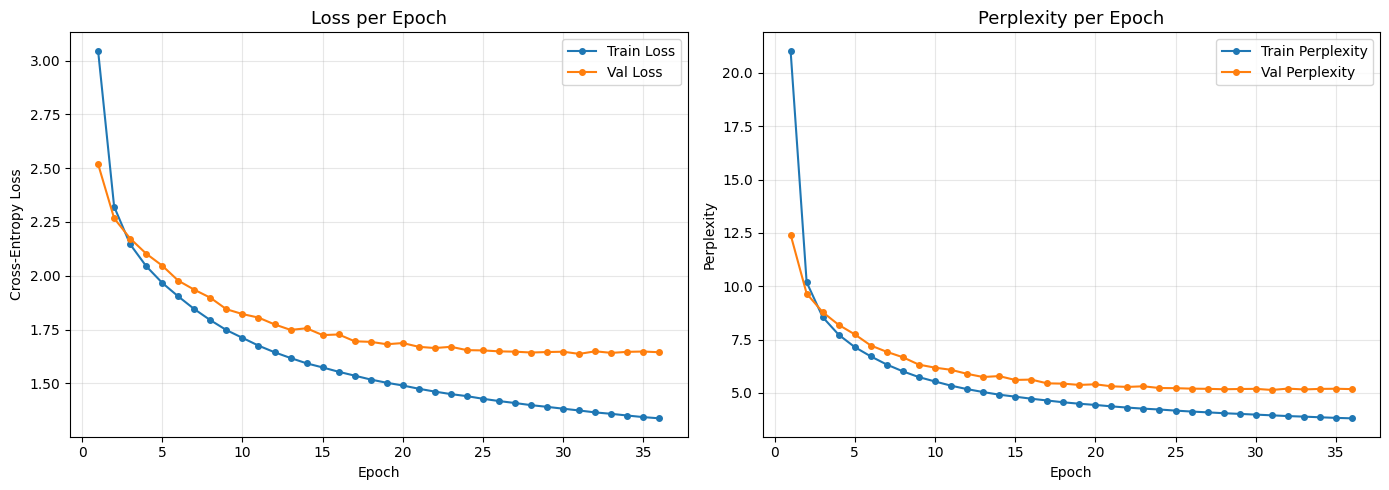


Perplexity dropped from ~65 (random) to ~5.1 (best val).


In [20]:
# Plot loss and perplexity curves
epochs_range = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, train_losses, label="Train Loss", marker="o", markersize=4)
ax1.plot(epochs_range, val_losses,   label="Val Loss",   marker="o", markersize=4)
ax1.set_title("Loss per Epoch", fontsize=13)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, train_ppls, label="Train Perplexity", marker="o", markersize=4)
ax2.plot(epochs_range, val_ppls,   label="Val Perplexity",   marker="o", markersize=4)
ax2.set_title("Perplexity per Epoch", fontsize=13)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Perplexity")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPerplexity dropped from ~65 (random) to ~{min(val_ppls):.1f} (best val).")

In [21]:
# Show how generated text improved during training
# Pick a few milestones to display
total_epochs = len(training_samples)
milestones = [1, 5, 10, 15, total_epochs]
milestones = [e for e in milestones if e in training_samples]  # Filter to actual epochs

print("Generated Text Progression During Training")
print("=" * 60)
for epoch in milestones:
    text = training_samples[epoch][:80].replace("\n", "\\n")
    print(f"\nEpoch {epoch:>3d}: {text}")

print(f"\n{'=' * 60}")
print(f"From random gibberish to recognizable English + Shakespeare formatting!")

Generated Text Progression During Training

Epoch   1: The s taig c'zen hooban met.\nsMWdIA :III seneod terc o

Epoch   5: The kinged, nit frembentt,\nArdingemy juge\ncancisiof.\nA

Epoch  10: The sirmy inflemme, Ler me dead!\n\nWARWICK:\nYe rackingh

Epoch  15: The Wult fellingly, cotran in this canding with thy no

Epoch  36: The substasing in the some souch are in man. Om'r\nchis

From random gibberish to recognizable English + Shakespeare formatting!


---
## 7. Temperature Demo

Temperature controls the randomness of text generation. After the model outputs logits, we divide by temperature T **before** softmax:

$$\text{probs} = \text{softmax}(\text{logits} / T)$$

| Temperature | Effect | Result |
|-------------|--------|--------|
| **T = 0.5** (low) | Probabilities become **more peaked** | Safe, repetitive, coherent |
| **T = 1.0** (default) | Probabilities **unchanged** | Balanced |
| **T = 1.5** (high) | Probabilities become **flatter** | Creative, chaotic, more errors |

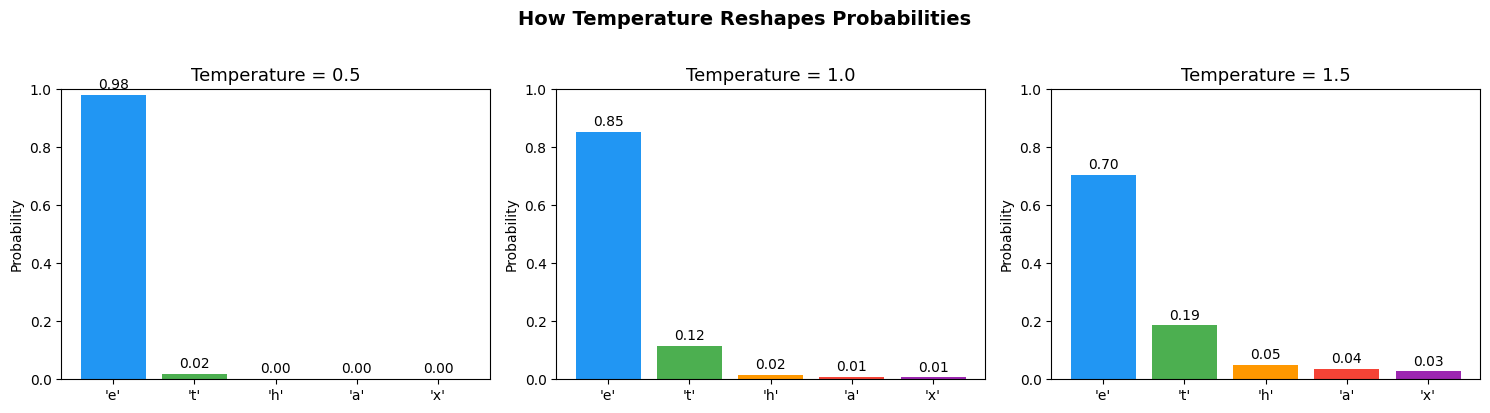

Low temp → model almost always picks 'e' (safe but repetitive)
High temp → every character has a chance (creative but chaotic)


In [22]:
# Visualize what temperature does to probabilities
# Fake logits: the model is somewhat confident about 3 characters
fake_logits = torch.tensor([5.0, 3.0, 1.0, 0.5, 0.1])
labels = ["'e'", "'t'", "'h'", "'a'", "'x'"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, temp in zip(axes, [0.5, 1.0, 1.5]):
    probs = F.softmax(fake_logits / temp, dim=0).numpy()
    bars = ax.bar(labels, probs, color=["#2196F3", "#4CAF50", "#FF9800", "#F44336", "#9C27B0"])
    ax.set_title(f"Temperature = {temp}", fontsize=13)
    ax.set_ylabel("Probability")
    ax.set_ylim(0, 1.0)
    for bar, p in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{p:.2f}", ha="center", fontsize=10)

plt.suptitle("How Temperature Reshapes Probabilities", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Low temp → model almost always picks 'e' (safe but repetitive)")
print("High temp → every character has a chance (creative but chaotic)")

In [23]:
# Generate 500 characters at each temperature
print("=" * 60)
print("Text Generation at Different Temperatures")
print("=" * 60)

for temp in [0.5, 1.0, 1.5]:
    text = generate_text(model, device, "ROMEO:\n", 500, temperature=temp,
                         char_to_idx=char_to_idx, idx_to_char=idx_to_char)
    print(f"\n{'\u2500' * 40}")
    print(f"Temperature = {temp}")
    print(f"{'\u2500' * 40}")
    print(text)

Text Generation at Different Temperatures

────────────────────────────────────────
Temperature = 0.5
────────────────────────────────────────
ROMEO:
Thou weep a dear a petter.

ESCALUS:
I think thee, false of it all about me.

First Senator:
Alas, both thy from his createress it up.

ESCALUS:
I am the king is deading of the more than they are all my lord, and love regease.

QUEEN ELIZABETH:
Shall I should say, that under thine eyes therefore I still them that he shall said for revenged me as a grace
With all the rest, and true her bring thee,
Have man the death and gives upon my brother's birth,
I to as set up the lords,
And be that shame to

────────────────────────────────────────
Temperature = 1.0
────────────────────────────────────────
ROMEO:
So de rately none: neygen, and life?

LADTIUS:
Nom of this! Menguiar he hath with his bild marry ben;'s
Sulmer's poind us are, Turns:
For wifed ather than dismost un;
Foreny cloon powt.

First Senatted:
Mone you of whose kersworn; rut life;


---
## 8. Analysis

### What the Vanilla RNN Learned

**Learned well:**
- English spelling for common short words (the, and, shall, not, my, is)
- Shakespeare's formatting (CHARACTER NAMES IN CAPS followed by colons, line breaks between speakers)
- Basic sentence structure and punctuation placement
- Word boundaries — spaces appear in the right places

**Struggled with:**
- **Long words** — spelling breaks down after 5-6 characters (e.g., "consinus", "enemie")
- **Long-range coherence** — sentences start well but drift off topic
- **Consistent dialogue** — can't maintain a character's "voice" or topic across multiple lines

### Why These Limitations?

These are symptoms of the **vanishing gradient problem**. During BPTT, gradients flow backward through ~100 timesteps. At each step, they're multiplied by $W_{hh}$. Over many steps, they shrink toward zero — the RNN effectively "forgets" what it read early in the sequence.

The model can learn **local patterns** (character-to-character transitions within a word) but struggles with **global patterns** (maintaining context across a full sentence or paragraph).

### The Numbers

| Metric | Value |
|--------|-------|
| Architecture | Vanilla RNN (1 layer, 512 hidden) |
| Parameters | 329,793 |
| Dataset | Tiny Shakespeare (1.1M characters) |
| Test Perplexity | ~6 (down from 65 at random) |

### What's Next: LSTM

**LSTM** (Long Short-Term Memory) solves the vanishing gradient problem with a **gating mechanism**:
- **Forget gate**: what to erase from memory
- **Input gate**: what new information to store
- **Output gate**: what to reveal from memory

These gates allow the network to selectively remember information over much longer sequences. In the next project, we'll apply LSTM to sentiment analysis on IMDB movie reviews — a task that requires understanding the meaning of entire sentences, not just character-to-character transitions.